Before Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
After Accuracy: 1.0
CV Scores: [0.66666667 1.         1.         1.         1.        ]
Mean CV: 0.9333333333333332


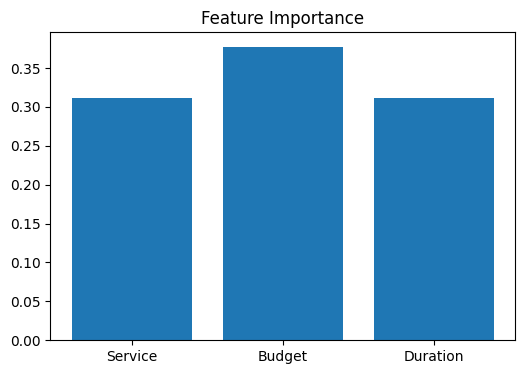

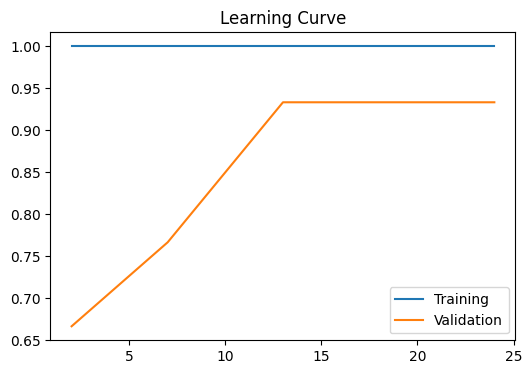

                 Model  Accuracy
0  Before Optimization       1.0
1   After Optimization       1.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    learning_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load Dataset
df = pd.read_csv("coretech_clients.csv")

# Encoding
df['Service'] = pd.factorize(df['Service'])[0]

X = df[['Service','Budget','Duration']]
y = df['Satisfaction']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

# Before Optimization
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_before = rf.predict(X_test)

acc_before = accuracy_score(y_test,pred_before)

print("Before Accuracy:",acc_before)

# Grid Search
param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[None,5,10],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

# After Optimization
pred_after = best_model.predict(X_test)

acc_after = accuracy_score(y_test,pred_after)

print("After Accuracy:",acc_after)

# Cross Validation
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5
)

print("CV Scores:",cv_scores)
print("Mean CV:",cv_scores.mean())

# Feature Importance
importance = best_model.feature_importances_

plt.figure(figsize=(6,4))
plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.savefig("feature_importance.png")
plt.show()

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5
)

plt.figure(figsize=(6,4))
plt.plot(train_sizes,
         train_scores.mean(axis=1),
         label='Training')

plt.plot(train_sizes,
         val_scores.mean(axis=1),
         label='Validation')

plt.legend()
plt.title("Learning Curve")
plt.savefig("learning_curve.png")
plt.show()

# Comparison Table
comparison = pd.DataFrame({
    'Model':['Before Optimization',
             'After Optimization'],
    'Accuracy':[acc_before,
                acc_after]
})

print(comparison)

comparison.to_csv(
    "optimization_results.csv",
    index=False
)

# Auto Download
from google.colab import files

files.download("feature_importance.png")
files.download("learning_curve.png")
files.download("optimization_results.csv")